# 05 - Generalization: lab to elderly care

The headline test. Train on the lab/university datasets (1-5, mostly young
adults), test on the elderly care datasets (6-7, ages up to 98). Fall is dropped
because the target sites barely recorded it, leaving a 5-class problem
(walk, sit, stand, pick, drink). We compare the within-source ceiling to the
cross-domain accuracy for both models.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import joblib
import radar_pipeline as rp
from sklearn.svm import SVC
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupKFold, GroupShuffleSplit
from sklearn.base import clone
from sklearn.metrics import confusion_matrix, accuracy_score

SOURCE, TARGET, CLASSES = [1, 2, 3, 4, 5], [6, 7], [1, 2, 3, 4, 5]
NAMES = [rp.ACTIVITY_NAMES[c] for c in CLASSES]

def load(dsets):
    X, meta = rp.load_cache(dsets)
    keep = np.isin(meta["activity"], CLASSES)
    return (X[keep], (meta["activity"][keep] - 1).astype(np.int64),
            meta["group"][keep])

Xs, ys, gs = load(SOURCE)
Xt, yt, gt = load(TARGET)
Fs, Ft = rp.feature_matrix(Xs), rp.feature_matrix(Xt)
Xs_db, Xt_db = rp.db_stack(Xs), rp.db_stack(Xt)
print(f"source {Xs.shape[0]} files / {len(set(gs))} subjects | "
      f"target {Xt.shape[0]} files / {len(set(gt))} subjects")

source 970 files / 66 subjects | target 587 files / 40 subjects


## Within-source ceiling (subject-independent CV on the lab pool)

In [2]:
svm = make_pipeline(StandardScaler(), SVC(C=10, gamma="scale", random_state=0))
gkf = GroupKFold(n_splits=5)
cv = [accuracy_score(ys[te], clone(svm).fit(Fs[tr], ys[tr]).predict(Fs[te]))
      for tr, te in gkf.split(Fs, ys, gs)]
print(f"SVM within-source CV: {np.mean(cv):.3f} +- {np.std(cv):.3f}")

SVM within-source CV: 0.891 +- 0.022


## Cross-domain: train on lab, test on care

In [3]:
svm_full = clone(svm).fit(Fs, ys)
svm_pred = svm_full.predict(Ft)
svm_acc = accuracy_score(yt, svm_pred)

# The CNN result is averaged over seeds: a single fine-tune is noisy on MPS and
# the cross-domain number swings several points run to run, so one seed is not a
# fair comparison.
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=0)
itr, iva = next(gss.split(Xs_db, ys, gs))
cnn_accs, cnn_pred = [], None
for seed in range(3):
    net = rp.make_cnn(len(CLASSES), pretrained=True)
    net, _ = rp.train_cnn(net, Xs_db[itr], ys[itr], Xs_db[iva], ys[iva],
                          epochs=20, lr=5e-4, batch=32, seed=seed)
    p = rp.cnn_predict(net, Xt_db)
    cnn_accs.append(accuracy_score(yt, p))
    if cnn_pred is None:
        cnn_pred = p           # seed 0, used for the confusion matrix
cnn_acc = float(np.mean(cnn_accs))
print(f"SVM source->target: {svm_acc:.3f}")
print(f"CNN source->target: {cnn_acc:.3f} +- {np.std(cnn_accs):.3f} "
      f"(seeds: {[round(a, 3) for a in cnn_accs]})")

SVM source->target: 0.767
CNN source->target: 0.761 +- 0.045 (seeds: [0.758, 0.707, 0.818])


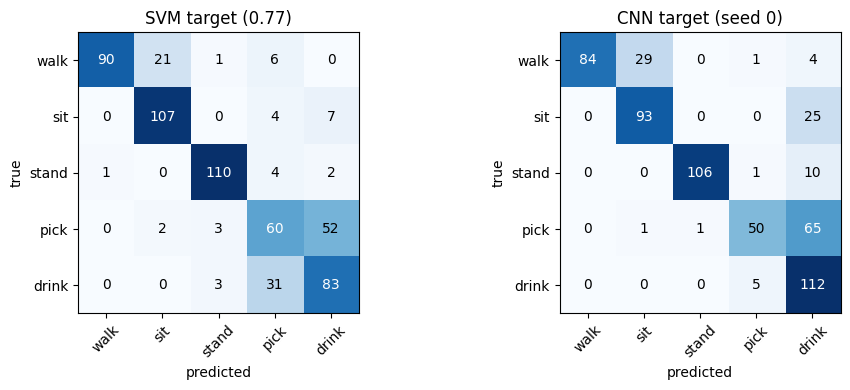

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
for a_, pred, ttl in [(ax[0], svm_pred, f"SVM target ({svm_acc:.2f})"),
                      (ax[1], cnn_pred, f"CNN target (seed 0)")]:
    cm = confusion_matrix(yt, pred)
    a_.imshow(cm, cmap="Blues")
    a_.set_xticks(range(5), NAMES, rotation=45); a_.set_yticks(range(5), NAMES)
    for i in range(5):
        for j in range(5):
            a_.text(j, i, cm[i, j], ha="center", va="center",
                    color="white" if cm[i, j] > cm.max() / 2 else "black")
    a_.set(xlabel="predicted", ylabel="true", title=ttl)
plt.tight_layout(); plt.show()

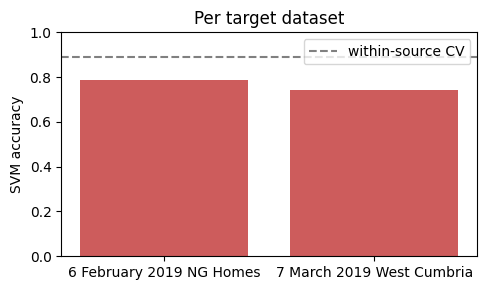

{6: 0.789, 7: 0.744}


In [5]:
fig, ax = plt.subplots(figsize=(5, 3))
accs = []
for d in TARGET:
    Xd, yd, _ = load([d])
    accs.append(accuracy_score(yd, svm_full.predict(rp.feature_matrix(Xd))))
ax.bar([rp.DATASET_NAMES[d].split(" Dataset")[0] for d in TARGET], accs,
       color="indianred")
ax.axhline(np.mean(cv), ls="--", c="gray", label="within-source CV")
ax.set(ylabel="SVM accuracy", title="Per target dataset", ylim=(0, 1)); ax.legend()
plt.tight_layout(); plt.show()
print({d: round(a, 3) for d, a in zip(TARGET, accs)})

## Conclusions

- SVM accuracy falls from ~0.89 within the lab pool to ~0.77 on the care sites:
  an honest ~12 point generalization gap, larger (~0.74) for West Cumbria.
- The CNN does **not** reliably generalize better than the SVM. Averaged over
  seeds it lands near the SVM (~0.77) with several points of run-to-run swing,
  while the SVM is deterministic. Extra model capacity buys no cross-domain
  robustness here, and its instability is itself a reason to prefer the simpler
  model; both are limited by the domain shift, not by model expressiveness.
- The errors are physical and concentrated in **pick vs drink**: in the elderly
  population these arm motions are slower and smaller, so their already-similar
  low-velocity Doppler signatures overlap further.
- Part of the gap is a **geometry shift** (notebook 02): the fixed range window,
  set on the lab data, captures only ~0.4-0.5 of the care-home return because
  those subjects stand closer to the radar.

Limitations and next steps: re-centre the range window per site, add a few care
recordings to training (domain adaptation), and report fall separately since the
care sites barely recorded it. The lab-only model is saved for reuse.

In [6]:
joblib.dump(svm_full, "../models/svm_lab.joblib")
print("saved ../models/svm_lab.joblib")

saved ../models/svm_lab.joblib
